In [12]:
import torch

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

In [4]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

In [5]:
import pandas as pd
from pathlib import Path

path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

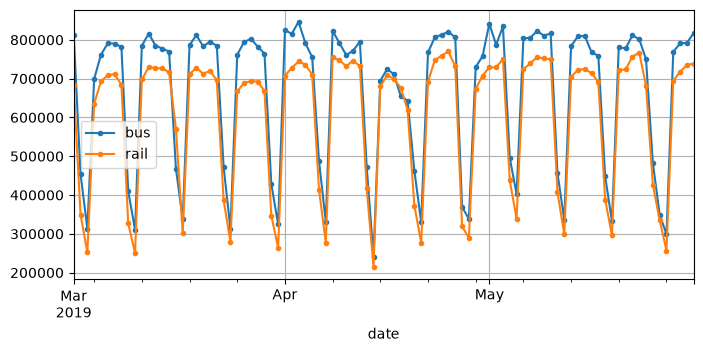

In [7]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

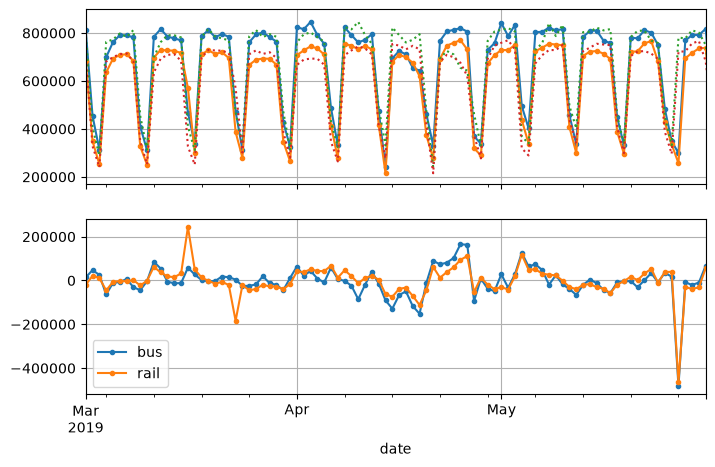

In [8]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot

plt.show()

In [9]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

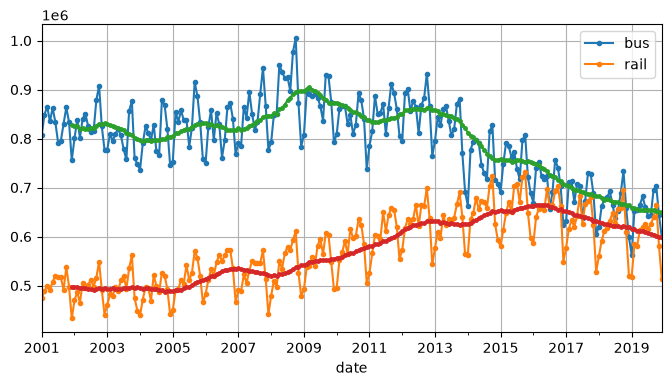

In [19]:
period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample('ME').mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False, marker='.', markersize=5)
plt.show()

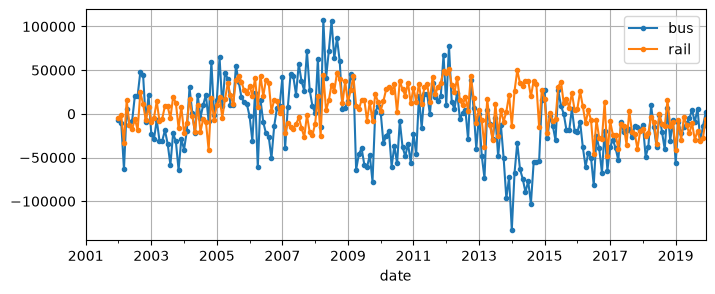

In [11]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
plt.show()

In [21]:
# ARMA (statstmodels)
# Prophet
# RNN

In [ ]:
# 1
# 2
# 3
# 4
# 5
# 6
# 7
# 8

# ---

# 1,2 -> 3
# 2,3 -> 4
# 3,4 -> 5
# 4,5 -> 6
# 5,6 -> 7
# 6,7 -> 8

# ----

# 1,2 -> (3)
# 2,(3) -> (4)
# (3),(4) -> (5) 

# 1,2,(3),(4),(5)



In [31]:
class Heyvan:
    def __init__(self, nov):
        self.nov = nov

class It(Heyvan):
    def __init__(self):
        super().__init__(nov='it')

it1 = It()
it1.nov

'it'

In [128]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        # if idx >= len(self):
        #     raise IndexError('aldjalsdfja')
        window = self.series[idx : idx + self.window_length] # [0:0+2]
        target = self.series[idx + self.window_length] # [2]
        return window, target

In [129]:
my_series = torch.tensor([
    [0],
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
])

my_dataset = TimeSeriesDataset(my_series, window_length=2)

In [130]:
for window, target in my_dataset:
    print(window, target)

tensor([[0],
        [1]]) tensor([2])
tensor([[1],
        [2]]) tensor([3])
tensor([[2],
        [3]]) tensor([4])
tensor([[3],
        [4]]) tensor([5])
tensor([[4],
        [5]]) tensor([6])


In [138]:
from torch.utils.data import DataLoader

train_data = DataLoader(my_dataset, batch_size=2, shuffle=True)
train_data

In [139]:
next(iter(train_data))

[tensor([[[4],
          [5]],
 
         [[0],
          [1]]]),
 tensor([[6],
         [2]])]

In [156]:
rail_train = torch.FloatTensor(df.loc["2016-01":"2018-12", ["rail"]].values / 1e6)
rail_valid = torch.FloatTensor(df.loc["2019-01":"2019-05", ["rail"]].values / 1e6)
rail_test = torch.FloatTensor(df.loc["2019-06":, ["rail"]].values / 1e6)

In [169]:
rail_train.shape

torch.Size([1096, 1])

In [171]:
(1096 - 56) / 32

32.5

In [172]:
window_length = 56
batch_size = 32

train_set = TimeSeriesDataset(rail_train, window_length=window_length)
test_set = TimeSeriesDataset(rail_test, window_length=window_length)
valid_set = TimeSeriesDataset(rail_valid, window_length=window_length)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size)
valid_loader = DataLoader(valid_set, batch_size=batch_size)

In [178]:
next(iter(train_loader))[0].shape

torch.Size([32, 56, 1])

In [179]:
next(iter(train_loader))[1].shape

torch.Size([32, 1])

In [180]:
from custom_utils import train, plot_history

In [181]:
1.7**2

2.8899999999999997

In [186]:
import torch.nn as nn
import torchmetrics

learning_rate = 0.003 
momentum=0.9

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=window_length, out_features=1)
).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum) # algorithm
criterion = nn.HuberLoss() # loss function
metric = torchmetrics.MeanAbsoluteError().to(device) # metric
n_epochs = 50

history = train(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    device=device,

)

Epoch: 1/50, Train Loss: 0.012, Train Metric: 0.124, Valid Metric: 0.093, Time: 0.15s
	Checkpoint, valid metric: 0.093
Epoch: 2/50, Train Loss: 0.006, Train Metric: 0.084, Valid Metric: 0.067, Time: 0.08s
	Checkpoint, valid metric: 0.067
Epoch: 3/50, Train Loss: 0.005, Train Metric: 0.072, Valid Metric: 0.059, Time: 0.08s
	Checkpoint, valid metric: 0.059
Epoch: 4/50, Train Loss: 0.004, Train Metric: 0.066, Valid Metric: 0.054, Time: 0.09s
	Checkpoint, valid metric: 0.054
Epoch: 5/50, Train Loss: 0.004, Train Metric: 0.063, Valid Metric: 0.052, Time: 0.08s
	Checkpoint, valid metric: 0.052
Epoch: 6/50, Train Loss: 0.004, Train Metric: 0.06, Valid Metric: 0.05, Time: 0.08s
	Checkpoint, valid metric: 0.050
Epoch: 7/50, Train Loss: 0.004, Train Metric: 0.059, Valid Metric: 0.049, Time: 0.08s
	Checkpoint, valid metric: 0.049
Epoch: 8/50, Train Loss: 0.004, Train Metric: 0.057, Valid Metric: 0.048, Time: 0.08s
	Checkpoint, valid metric: 0.048
Epoch: 9/50, Train Loss: 0.004, Train Metric: 0.05

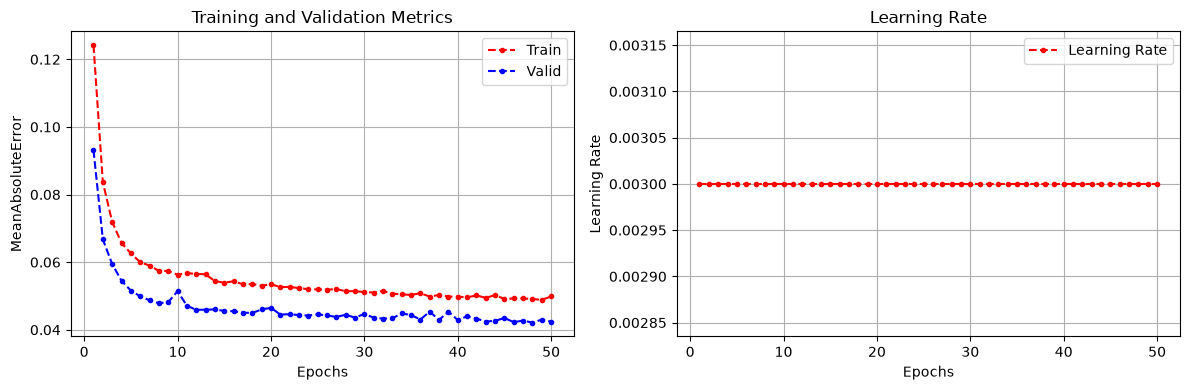

In [187]:
plot_history(history, metric)